# Probability, Random Variables, and Covariance

**Course Title:** ENM 3800: Learning from Data

**Instructor:** Eva Dyer

**Lecture:** 8 — Oct 6

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nerdslab/learningfromdata-course/blob/main/notebooks/Notebook_3/Notebook_3a_Probability_and_Covariance.ipynb)

This notebook covers:

1. Probability and random variables
2. Covariance and correlation

Big theme:

> Data are variable. Statistical thinking helps us decide how much confidence to place in a pattern.

In [2]:
# Setup

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

### Visualization Helpers

Run the setup cell below once. These helper functions make the later visualizations cleaner.


In [3]:
def clean_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return ax


def show_widget_or_fallback(widget_fn, fallback_fn):
    """Try to show an ipywidgets interaction; otherwise run a static fallback."""
    try:
        import ipywidgets as widgets
        from IPython.display import display

        display(widget_fn(widgets))
    except Exception as e:
        print("Interactive widgets are not available in this environment.")
        print("Running a static example instead.")
        fallback_fn()
        print(e)

## Probability and Random Variables

### What is probability?

We will think of **probability** as a way to describe uncertainty about outcomes of a process.

- A *random experiment* is something we can conceptually repeat (coin flips, measuring height, etc.).
- The **sample space** is the set of all possible outcomes, usually denoted by $\Omega$. (coin flip: $\Omega = \{\text{heads}, \text{tails}\}$; person's height: $\Omega = \mathbb R^+$).

- A **probability distribution** assigns a probability $P(\omega)$ to each outcome $\omega \in \Omega$, or to ranges of outcomes in the continuous case. \
    A valid probability obeys **three rules**:
    1. **Non-negativity:** every event $A$ has $P(A) \ge 0$. Probabilities are never negative.
    2. **Normalization:** the whole sample space has probability one, $P(\Omega) = 1$. *Something* in $\Omega$ must happen.
    3. **Additivity:** if two events $A$ and $B$ are *mutually exclusive* (they cannot both occur, $A \cap B = \varnothing$), then
    $$
    P(A \cup B) = P(A) + P(B).
    $$
    A few consequences that follow directly from these rules:

    - $0 \le P(A) \le 1$ for any event.
    - $P(A^c) = 1 - P(A)$, with $A^c$ define as $A$ does *not* happen.


In data analysis, we rarely know the true distribution exactly, but we model it.



### Random variables

A **random variable** \(X\) is a function that maps outcomes to numbers:

$$
X: \Omega \rightarrow \mathbb{N} \;\text{(discrete)} \quad\text{or}\quad X: \Omega \rightarrow \mathbb{R} \;\text{(continuous)}
$$
more details

Examples:

- $X$ = number of heads in 10 coin flips.
- $X$ = height (in cm) of a randomly chosen person from a population.
- $X$ = daily temperature in Philadelphia.

We use random variables to connect uncertain processes to numerical data we can analyze.
Once we have a random variable, the natural question is: *how is its probability spread across the values it can take?*
That spread is called the **distribution** of $X$.
For a discrete random variable we describe it by listing the probability of each value, $P(X = x)$, the example below makes this concrete.

**Example (discrete).** Let $X$ be the result of rolling a fair six-sided die. The sample space is $\Omega = \{1, 2, 3, 4, 5, 6\}$, and the distribution assigns equal probability to each outcome:

$$
P(X = k) = \frac{1}{6}, \qquad k = 1, 2, \dots, 6.
$$

This is a **uniform distribution**: the probabilities are flat across all outcomes, and they sum to $1$ as the rules require. Listing $P(X=k)$ for every outcome *is* the distribution.




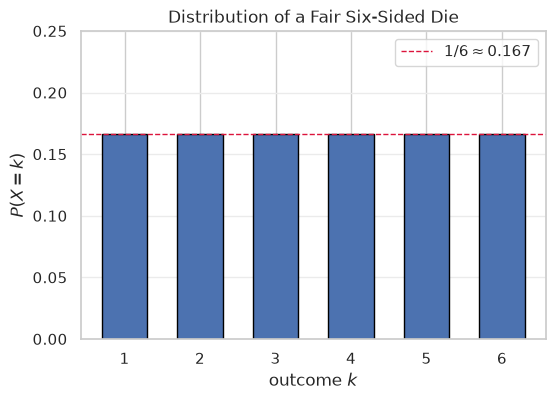

Probabilities: [0.167 0.167 0.167 0.167 0.167 0.167]
Sum of probabilities: 0.9999999999999999


In [4]:
#| code-fold: true
import matplotlib.pyplot as plt

# Fair six-sided die: each face k = 1..6 has probability 1/6
faces = np.arange(1, 7)
pmf = np.full(6, 1 / 6)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(faces, pmf, width=0.6, color="#4C72B0", edgecolor="black")
ax.set_xticks(faces)
ax.set_ylim(0, 0.25)
ax.set_xlabel("outcome $k$")
ax.set_ylabel("$P(X = k)$")
ax.set_title("Distribution of a Fair Six-Sided Die")
ax.axhline(
    1 / 6, color="crimson", linestyle="--", linewidth=1, label="$1/6 \\approx 0.167$"
)
ax.grid(True, axis="y", color="0.92")
ax.legend()
plt.show()

print("Probabilities:", np.round(pmf, 3))
print("Sum of probabilities:", pmf.sum())  # must equal 1

### Expectation and variance (intuitively)

- The **expected value** $\mathbb{E}[X]$ is the long-run average of $X$ over many repetitions.
- The **variance** $\mathrm{Var}(X)$ measures how spread out the values of \(X\) are around the mean.

Formally, for a discrete random variable:

$$
\mathbb{E}[X] = \sum_x x \, P(X = x), \quad
\mathrm{Var}(X) = \mathbb{E}[(X - \mathbb{E}[X])^2].
$$

In this course, we mostly use these ideas conceptually and estimate them from data.


### Example: Coin flip simulation

Let's make the ideas above concrete with a random variable we can simulate.

Define $X$ = **the number of heads in 10 coin flips**. Each "experiment" is 10 flips of a fair coin, so $X$ takes values in $\{0, 1, \dots, 10\}$. By repeating the experiment many times, we can:

- see the **distribution** of $X$ (how often each number of heads occurs), and
- estimate its **expected value** $\mathbb{E}[X]$ from the data — the long-run average number of heads.

Since each flip is heads with probability $\tfrac{1}{2}$, we expect around $5$ heads on average. The simulation below lets us check that.



E[X] (mean) ≈ 4.996


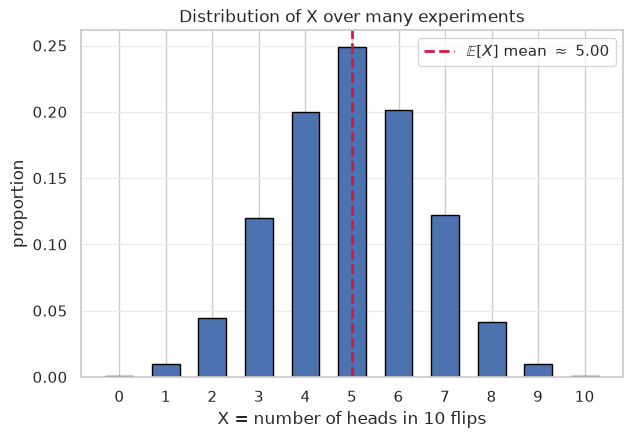

In [5]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(0)

# X = number of heads in 10 coin flips (one experiment).
# Repeat the experiment many times to see the distribution of X.
n_flips = 10
n_experiments = 10000

# 1 = heads, 0 = tails. Each row is one experiment of 10 flips;
# summing a row gives the number of heads in that experiment.
flips = rng.integers(0, 2, size=(n_experiments, n_flips))
X = flips.sum(axis=1)  # each value is in 0..10

# Estimate the mean from the data
sample_mean = X.mean()
print(f"E[X] (mean) ≈ {sample_mean:.3f}")

values = np.arange(0, n_flips + 1)
emp_pmf = np.array([np.mean(X == k) for k in values])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(values, emp_pmf, width=0.6, color="#4C72B0", edgecolor="black")
ax.axvline(
    sample_mean,
    color="crimson",
    linestyle="--",
    linewidth=2,
    label=rf"$\mathbb{{E}}[X]$ mean $\approx$ {sample_mean:.2f}",
)
ax.set_xticks(values)
ax.set_xlabel("X = number of heads in 10 flips")
ax.set_ylabel("proportion")
ax.set_title("Distribution of X over many experiments")
ax.grid(True, axis="y", color="0.92")
ax.legend()
plt.show()

#### Quick Check

1. Where does the red mean line fall, and why is it close to 5?
2. Change `n_experiments` to a small number (e.g. 50) and rerun. Does the distribution look smooth, or bumpy? What happens when you set it back to 10,000?
3. Is the value of $X$ ever far from the mean (like 1 or 9 heads)? How often, compared to values near 5?



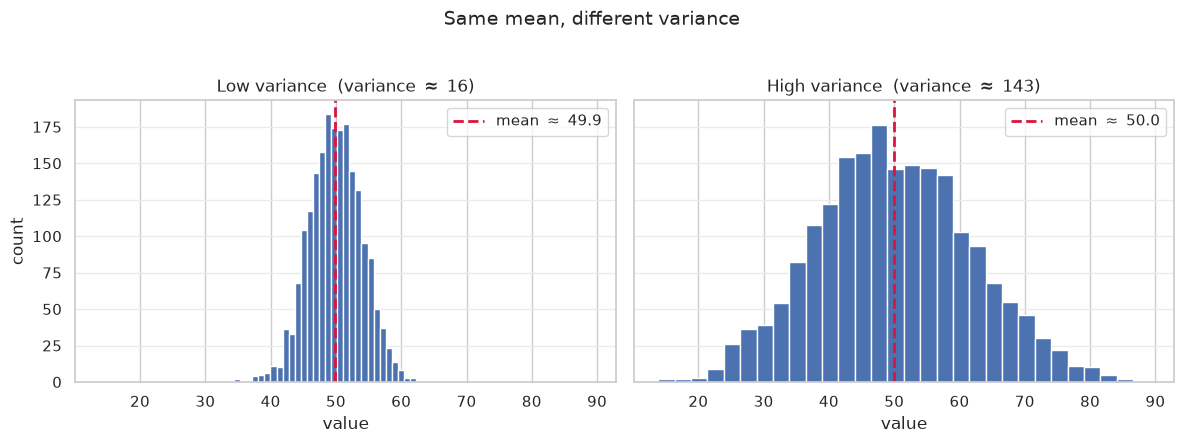

In [6]:
#| code-fold: true
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(0)

# Two made-up datasets with the SAME mean (50) but different spread.
low_var = rng.normal(loc=50, scale=4, size=2000)  # tightly clustered
high_var = rng.normal(loc=50, scale=12, size=2000)  # widely spread

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True, sharey=True)

for ax, data, name in zip(axes, [low_var, high_var], ["Low variance", "High variance"]):
    ax.hist(data, bins=30, color="#4C72B0", edgecolor="white")
    ax.axvline(
        data.mean(),
        color="crimson",
        linestyle="--",
        linewidth=2,
        label=f"mean $\\approx$ {data.mean():.1f}",
    )
    ax.set_title(f"{name}  (variance $\\approx$ {data.var():.0f})")
    ax.set_xlabel("value")
    ax.grid(True, axis="y", color="0.92")
    ax.legend()

axes[0].set_ylabel("count")
fig.suptitle("Same mean, different variance", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#### Quick Check
1. Both plots are centered at the same place. If you were only told the **mean**, could you tell the two distributions apart? Why not?
2. Which one has the larger variance, and how can you see that from the shape of the histogram?
3. In your own words: what does **variance** measure that the **mean** does not?

The takeaway: the mean tells us *where* a distribution is centered, while the variance tells us *how spread out* it is. We usually need both to describe data.

## Covariance and Correlation

### Covariance

When we have **two random variables** \(X\) and \(Y\), we may want to know whether they tend to move together.

The **covariance** is defined as:

$$
\mathrm{Cov}(X, Y) = \mathbb{E}[(X - \mathbb{E}[X])(Y - \mathbb{E}[Y])].
$$

- If $\mathrm{Cov}(X, Y) > 0$, large values of $X$ tend to go with large values of \(Y\).
- If $\mathrm{Cov}(X, Y) < 0$, large values of $X$ tend to go with small values of \(Y\).
- If $\mathrm{Cov}(X, Y) \approx 0$, there may be no linear relationship.

**Example.**

Height and the chance of playing in the NBA tend to move together, since taller people are more likely to play, so their covariance is positive.
By contrast, a car's mileage and its resale price move in opposite directions, because higher mileage generally means a lower price, so their covariance is negative.


Note that the covariance of a variable with itself is just its variance: $\mathrm{Cov}(X, X) = \mathrm{Var}(X)$.

### Correlation

The **correlation** is a normalized version of covariance:

$$
\rho_{X,Y} = \frac{\mathrm{Cov}(X, Y)}{\sqrt{\mathrm{Var}(X)\,\mathrm{Var}(Y)}}.
$$

It takes values in \([-1, 1]\) and is easier to compare across different variable scales.

We will mostly estimate covariance and correlation from data.


### Covariance as the Shape of a Data Cloud

Covariance is not just a formula. It describes the **shape** of data.

For two features, the covariance matrix summarizes:

- how spread out feature 1 is,
- how spread out feature 2 is,
- whether the two features move together,
- which directions contain the most variation.

A round cloud means the two features have similar variance and little correlation. A stretched cloud means there is more variation in one direction. A tilted cloud means the features are correlated.


In [7]:
from matplotlib.patches import Ellipse


def make_covariance(std_x=2.0, std_y=0.6, rho=0.7):
    """Create a 2D covariance matrix from standard deviations and correlation."""
    cov_xy = rho * std_x * std_y
    return np.array([[std_x**2, cov_xy], [cov_xy, std_y**2]])


def eig_sorted(matrix):
    """Eigenvalues/eigenvectors sorted from largest to smallest eigenvalue."""
    vals, vecs = np.linalg.eigh(matrix)
    order = np.argsort(vals)[::-1]
    return vals[order], vecs[:, order]


def add_covariance_ellipse(ax, mean, cov, n_std=2.0, edgecolor="black", linewidth=2):
    vals, vecs = eig_sorted(cov)
    width, height = 2 * n_std * np.sqrt(vals)
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))

    ellipse = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        facecolor="none",
        edgecolor=edgecolor,
        linewidth=linewidth,
    )
    ax.add_patch(ellipse)


def add_covariance_eigenvectors(ax, mean, cov, colors=("crimson", "darkorange")):
    vals, vecs = eig_sorted(cov)

    for i in range(2):
        direction = vecs[:, i]
        length = np.sqrt(vals[i])
        vector = direction * length
        ax.arrow(
            mean[0],
            mean[1],
            vector[0],
            vector[1],
            color=colors[i],
            width=0.025,
            head_width=0.18,
            length_includes_head=True,
            label=f"eigenvector {i + 1}, eigenvalue={vals[i]:.2f}",
        )


def plot_covariance_geometry(std_x=2.0, std_y=0.6, rho=0.7, n=600, seed=0):
    rng = np.random.default_rng(seed)
    cov = make_covariance(std_x=std_x, std_y=std_y, rho=rho)
    X_cov = rng.multivariate_normal([0, 0], cov, size=n)

    sample_mean = X_cov.mean(axis=0)
    sample_cov = np.cov(X_cov, rowvar=False)
    vals, vecs = eig_sorted(sample_cov)

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(X_cov[:, 0], X_cov[:, 1], s=18, alpha=0.3)
    add_covariance_ellipse(ax, sample_mean, sample_cov)
    add_covariance_eigenvectors(ax, sample_mean, sample_cov)
    ax.scatter(sample_mean[0], sample_mean[1], color="black", s=50, label="mean")
    ax.axhline(0, color="gray", linewidth=1)
    ax.axvline(0, color="gray", linewidth=1)
    ax.set_xlim(-7, 7)
    ax.set_ylim(-7, 7)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("feature 1")
    ax.set_ylabel("feature 2")
    ax.set_title(f"Covariance Geometry: std_x={std_x}, std_y={std_y}, rho={rho}")
    ax.legend(loc="upper left", fontsize=9)
    plt.show()

    print("Sample covariance matrix:")
    print(np.round(sample_cov, 3))
    print("\nEigenvalues:", np.round(vals, 3))
    print("Eigenvectors:\n", np.round(vecs, 3))

#### Example: A Tilted Cloud

The long eigenvector points in the direction of greatest variation. The short eigenvector points in the direction of least variation.

This is the geometric idea that will later become PCA.


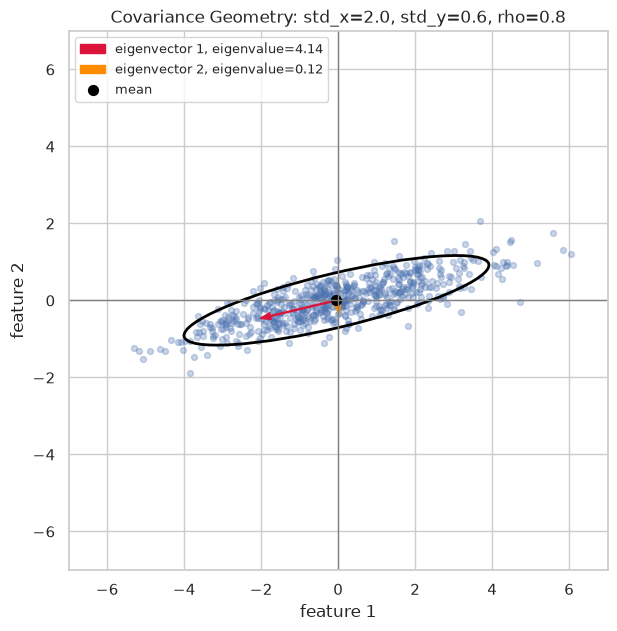

Sample covariance matrix:
[[3.921 0.905]
 [0.905 0.338]]

Eigenvalues: [4.137 0.123]
Eigenvectors:
 [[-0.973  0.232]
 [-0.232 -0.973]]


In [8]:
plot_covariance_geometry(std_x=2.0, std_y=0.6, rho=0.8, n=600, seed=3)

#### Compare Three Covariance Shapes

Run the next cell to compare:

1. round data,
2. stretched data,
3. tilted correlated data.


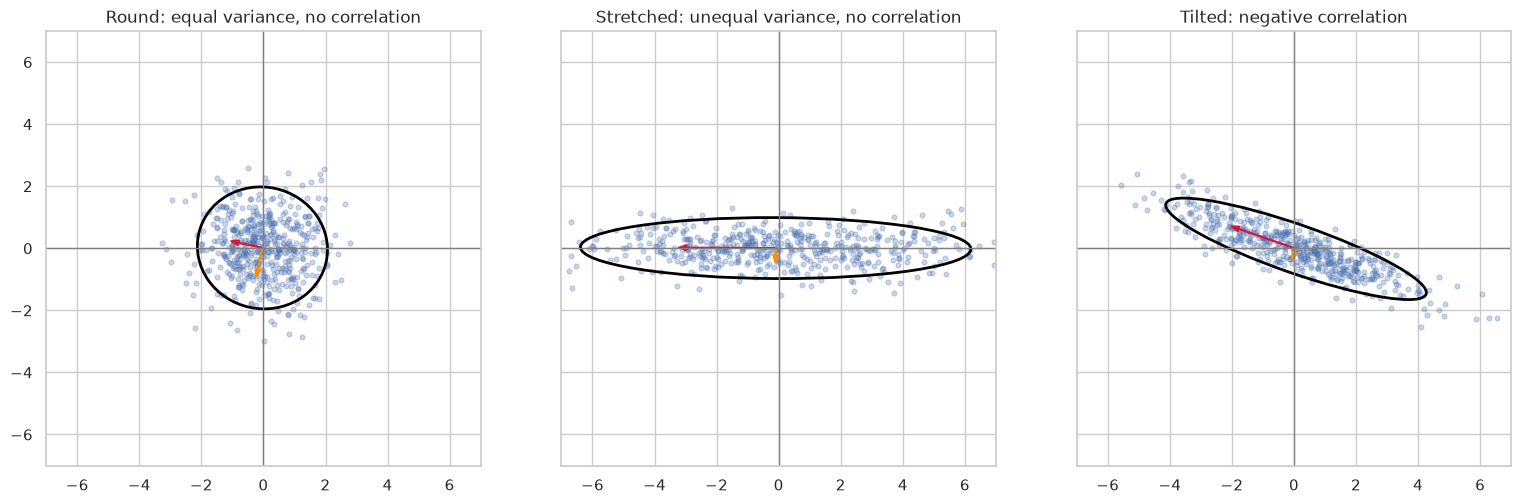

In [9]:
#| code-fold: true
examples = [
    (1.0, 1.0, 0.0, "Round: equal variance, no correlation"),
    (3.0, 0.5, 0.0, "Stretched: unequal variance, no correlation"),
    (2.0, 0.8, -0.85, "Tilted: negative correlation"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)

for ax, (std_x, std_y, rho, title) in zip(axes, examples):
    rng = np.random.default_rng(4)
    cov = make_covariance(std_x, std_y, rho)
    X_cov = rng.multivariate_normal([0, 0], cov, size=500)
    sample_mean = X_cov.mean(axis=0)
    sample_cov = np.cov(X_cov, rowvar=False)

    ax.scatter(X_cov[:, 0], X_cov[:, 1], s=12, alpha=0.28)
    add_covariance_ellipse(ax, sample_mean, sample_cov)
    add_covariance_eigenvectors(ax, sample_mean, sample_cov)
    ax.axhline(0, color="gray", linewidth=1)
    ax.axvline(0, color="gray", linewidth=1)
    ax.set_xlim(-7, 7)
    ax.set_ylim(-7, 7)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title)

plt.tight_layout()
plt.show()

#### Exercise: Read the Shape

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nerdslab/learningfromdata-course/blob/main/notebooks/Notebook_3/Notebook_3a_Probability_and_Covariance.ipynb#scrollTo=ex-read-shape)

For each panel above, answer:

1. Which feature has more variance?
2. Are the features positively correlated, negatively correlated, or weakly correlated?
3. Which direction does the first eigenvector point?
4. What does the largest eigenvalue mean in words?


### Interactive Demo: Covariance Shape Explorer

Use the sliders to change the standard deviation of each feature and the correlation between them.


In [10]:
def covariance_widget(widgets):
    return widgets.interactive(
        plot_covariance_geometry,
        std_x=widgets.FloatSlider(
            value=2.0, min=0.2, max=4.0, step=0.1, description="std x"
        ),
        std_y=widgets.FloatSlider(
            value=0.6, min=0.2, max=4.0, step=0.1, description="std y"
        ),
        rho=widgets.FloatSlider(
            value=0.7, min=-0.95, max=0.95, step=0.05, description="rho"
        ),
        n=widgets.IntSlider(value=600, min=50, max=2000, step=50, description="n"),
        seed=widgets.IntSlider(value=0, min=0, max=20, step=1, description="seed"),
    )


show_widget_or_fallback(
    covariance_widget,
    lambda: plot_covariance_geometry(std_x=2.0, std_y=0.6, rho=0.7, n=600, seed=0),
)

interactive(children=(FloatSlider(value=2.0, description='std x', max=4.0, min=0.2), FloatSlider(value=0.6, de…

#### Exercise: Covariance Explorer

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nerdslab/learningfromdata-course/blob/main/notebooks/Notebook_3/Notebook_3a_Probability_and_Covariance.ipynb#scrollTo=ex-covariance-explorer)

Use the sliders.

1. Set `rho = 0`. What happens to the ellipse orientation?
2. Set `std_x` much larger than `std_y`. What happens to the eigenvalues?
3. Set `rho` close to 1. What happens to the shape?
4. Set `rho` close to -1. How does the direction change?
5. Why does this matter for dimensionality reduction and PCA?


### Example: Simulating correlated variables


Sample covariance: 2.0098281391085777
Sample correlation: 0.9716925177395694


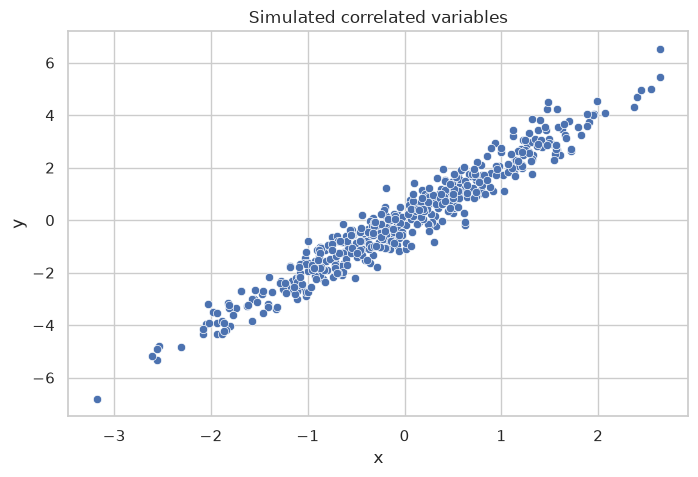

In [11]:
# Simulate two correlated variables
n = 500
x = np.random.normal(0, 1, size=n)
noise = np.random.normal(0, 0.5, size=n)
y = 2 * x + noise  # y is roughly a linear function of x

print("Sample covariance:", np.cov(x, y, bias=False)[0, 1])
print("Sample correlation:", np.corrcoef(x, y)[0, 1])

sns.scatterplot(x=x, y=y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Simulated correlated variables")
plt.show()

#### Coding Challenge:

You can modify the relationship between `x` and `y` above (e.g., change the slope or noise level) and see how the covariance and correlation change.

### Correlation in a real dataset

We will use the `penguins` dataset from `seaborn` and look at relationships between numeric features.


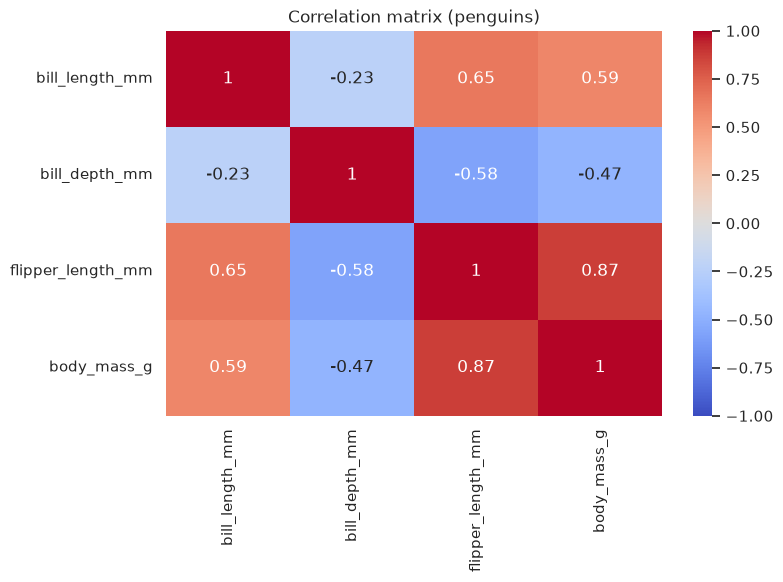

In [12]:
#| code-fold: true
penguins = sns.load_dataset("penguins").dropna()
numeric_cols = penguins.select_dtypes(include=[np.number]).columns
corr = penguins[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation matrix (penguins)")
plt.show()

#### Coding Challenge:
Look at the correlation matrix. Which pairs of variables appear to be most strongly related? Which are weakly related?


In [13]:
## Coding Cell

### Visual Exercise: Beyond the Correlation Matrix

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nerdslab/learningfromdata-course/blob/main/notebooks/Notebook_3/Notebook_3a_Probability_and_Covariance.ipynb#scrollTo=ex-beyond-correlation-matrix)

A correlation matrix gives a compact summary, but it can hide important structure.

A scatterplot matrix lets us see relationships, outliers, clusters, and nonlinear patterns.


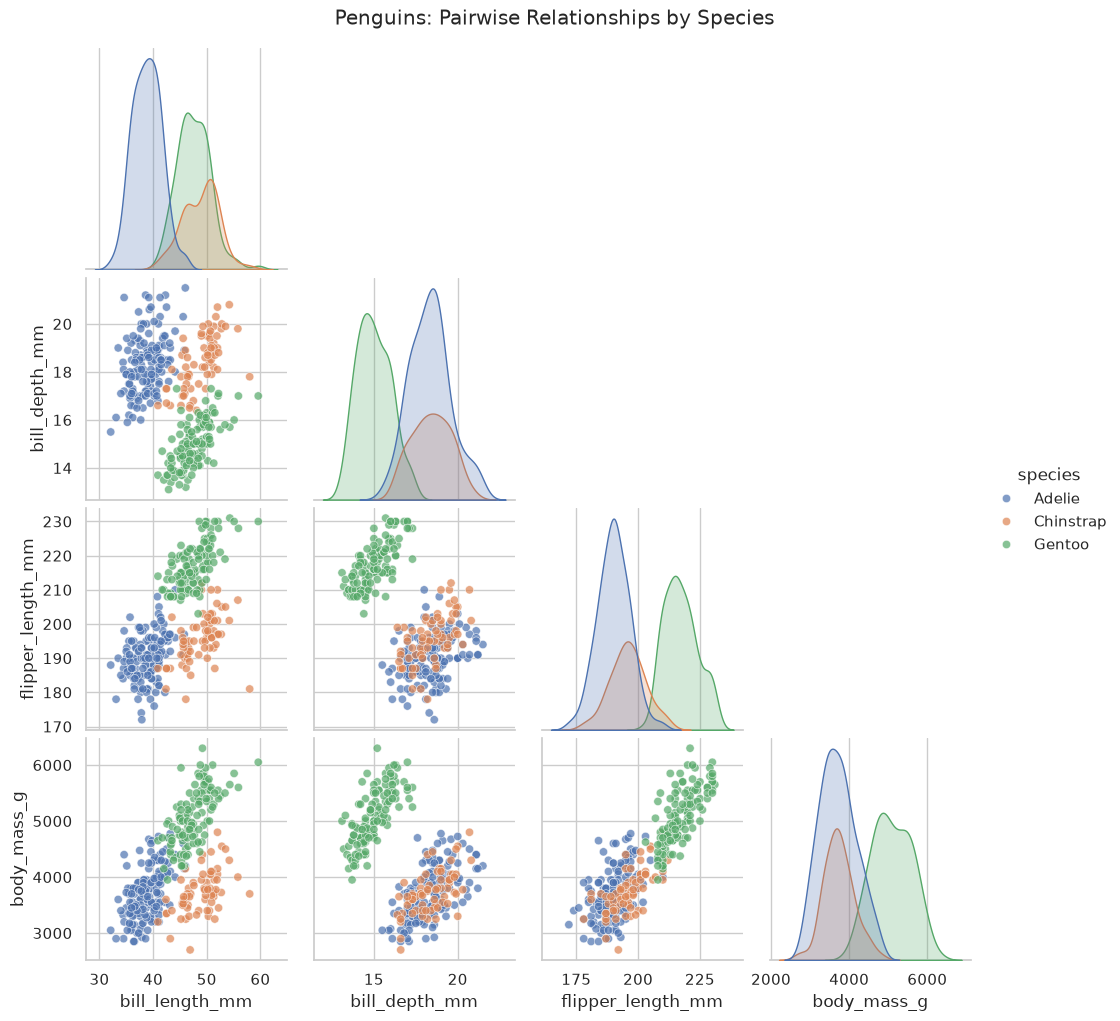

In [14]:
sns.pairplot(
    penguins,
    vars=["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"],
    hue="species",
    corner=True,
    plot_kws={"alpha": 0.7},
)
plt.suptitle("Penguins: Pairwise Relationships by Species", y=1.02)
plt.show()

#### Exercise: Correlation Plus Context

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nerdslab/learningfromdata-course/blob/main/notebooks/Notebook_3/Notebook_3a_Probability_and_Covariance.ipynb#scrollTo=ex-correlation-plus-context)

Choose one pair of variables from the pairplot.

1. Is the relationship positive, negative, or weak?
2. Does the relationship look the same within each species?
3. Is the overall correlation possibly influenced by species differences?
4. What would be misleading about reporting only one correlation number?
